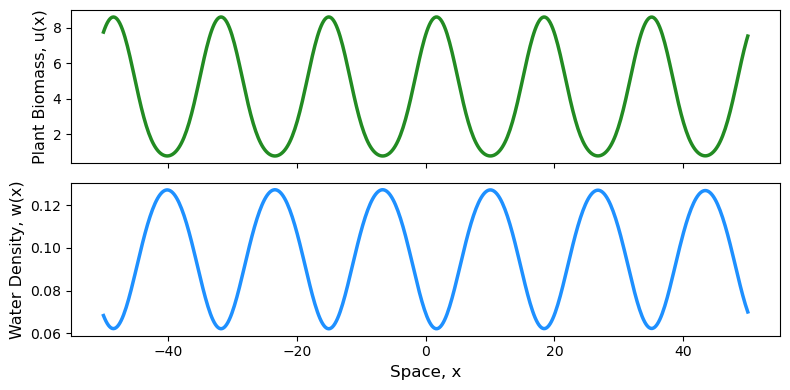

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#Parameters
A = 2.0
B = 0.450
d = 500.0

#Domain
L = 200.0
N = 1024
dx = L / N
x = np.linspace(-L/2, L/2, N, endpoint=False)

#Time
T  = 1000.0
dt = 0.05
nsteps = int(round(T/dt))

#Initial conditions
u_star = (A + np.sqrt(A**2 - 4*B**2)) / (2*B)
w_star = A / (1 + u_star**2)

rng = np.random.default_rng(0)
perturbation_mask = np.abs(x) < L/4
u = u_star * np.ones(N) + 0.01 * rng.standard_normal(N) * perturbation_mask
w = w_star * np.ones(N) + 0.01 * rng.standard_normal(N) * perturbation_mask

#IMEX Fourier step (periodic)
k = 2*np.pi*np.fft.fftfreq(N, d=dx)
den_u = 1.0 + dt*(k**2)
den_w = 1.0 + dt*d*(k**2)

for _ in range(nsteps):
    Ru = w*u*u - B*u
    Rw = A - w - w*u*u

    u_hat = np.fft.fft(u)
    w_hat = np.fft.fft(w)

    u = np.fft.ifft((u_hat + dt*np.fft.fft(Ru)) / den_u).real
    w = np.fft.ifft((w_hat + dt*np.fft.fft(Rw)) / den_w).real

    u[u < 0] = 0.0
    w[w < 0] = 0.0

#Plotting u(x) and w(x)
plot_halfwidth = 50.0
mask = np.abs(x) <= plot_halfwidth

fig, ax = plt.subplots(2, 1, figsize=(8, 4), sharex=True)

ax[0].plot(x[mask], u[mask],  lw=2.5, color= "forestgreen")
ax[0].set_ylabel("Plant Biomass, u(x)", fontsize=11.5)

ax[1].plot(x[mask], w[mask],  lw=2.5, color = "dodgerblue")
ax[1].set_xlabel("Space, x", fontsize=12)
ax[1].set_ylabel("Water Density, w(x)", fontsize=11.5)

plt.tight_layout()
plt.savefig("Numeric Simulation with Diffussion only.pdf", format="pdf")  
plt.show()
